# STEP 03 — BatteryEnvironment Design

Ez a projekt legfontosabb mérnöki notebookjai közé tartozik. Itt épül fel a kapcsolat az **Electrical Engineering** és a **Reinforcement Learning** között: az agent csak actiont kér, de az environment dönti el, hogy abból fizikailag mi hajtható végre, hogyan változik a SOC, mennyi energia kerül a hálózatból vételezésre és milyen reward jár.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. Agent ↔ Environment visszacsatolási hurok

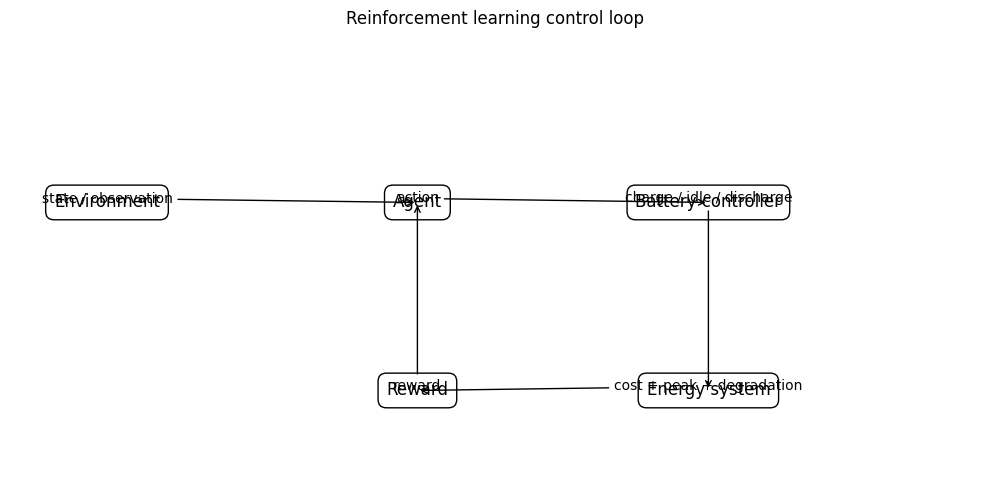

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
boxes = {
    "Environment": (0.10, 0.62), "Agent": (0.42, 0.62), "Battery controller": (0.72, 0.62),
    "Energy system": (0.72, 0.20), "Reward": (0.42, 0.20)
}
for label, (x,y) in boxes.items():
    ax.text(x, y, label, ha="center", va="center", fontsize=12, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black"))
ax.annotate("state / observation", xy=boxes["Agent"], xytext=boxes["Environment"], arrowprops=dict(arrowstyle="->"), ha="center")
ax.annotate("action", xy=boxes["Battery controller"], xytext=boxes["Agent"], arrowprops=dict(arrowstyle="->"), ha="center")
ax.annotate("charge / idle / discharge", xy=boxes["Energy system"], xytext=boxes["Battery controller"], arrowprops=dict(arrowstyle="->"), ha="center")
ax.annotate("cost + peak + degradation", xy=boxes["Reward"], xytext=boxes["Energy system"], arrowprops=dict(arrowstyle="->"), ha="center")
ax.annotate("reward", xy=boxes["Agent"], xytext=boxes["Reward"], arrowprops=dict(arrowstyle="->"), ha="center")
ax.set_title("Reinforcement learning control loop")
fig.tight_layout(); fig.savefig(FIG_DIR / "nb03_01_agent_environment_loop.png", dpi=170, bbox_inches="tight")
plt.show()

## 2. Environment példány létrehozása

A környezet Gymnasium-kompatibilis API-t követ: `reset()` observationt ad, a `step(action)` pedig `(next_observation, reward, terminated, truncated, info)` struktúrát. Ha a `gymnasium` package nincs telepítve, a repository tartalmaz könnyű fallback osztályokat, hogy az oktatási core továbbra is fusson.

In [3]:
from battery_rl.environment import BatteryEnvironment
env = build_env(train, cfg, random_start=False)
print("Observation columns:", env.obs_columns)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Episode length:", env.episode_hours, "hours")

Observation columns: ['soc', 'electricity_price_eur_per_kwh', 'electricity_demand_kw', 'renewable_generation_kw', 'hour_of_day']
Action space: <battery_rl.environment.battery_env._Discrete object at 0x7f64b6f91a90>
Observation space: <battery_rl.environment.battery_env._Box object at 0x7f64b6f91010>
Episode length: 24 hours


## 3. Battery specification — fizikai korlátok

In [4]:
battery_spec = pd.Series(env.spec.__dict__, name="value")
display(battery_spec.to_frame())

,value
capacity_kwh,120.000
initial_soc,0.500
min_soc,0.100
max_soc,0.900
max_charge_kw,30.000
max_discharge_kw,30.000
charging_efficiency,0.950
discharging_efficiency,0.950
timestep_hours,1.000
feed_in_tariff_eur_per_kwh,0.045


A SOC nem egy tetszőleges szám: `SOC = stored_energy / capacity`. A `min_soc` és `max_soc` üzemi korlát. A töltési és kisütési teljesítményt egyszerre korlátozza a névleges power limit **és** az, hogy fizikailag mennyi energia fér még be / vehető még ki.

## 4. Observation: nyers state vs normalizált observation

In [5]:
obs, info = env.reset(seed=42, options={"start_index": 0})
raw = info["raw_state"]
obs_table = pd.DataFrame({"feature": env.obs_columns, "raw_value": raw, "normalized_observation": obs})
display(obs_table)

,feature,raw_value,normalized_observation
0,soc,0.500000,0.500000
1,electricity_price_eur_per_kwh,0.112899,0.225799
2,electricity_demand_kw,44.164726,0.421487
3,renewable_generation_kw,4.963247,0.051019
4,hour_of_day,0.000000,0.000000


### Miért kapja meg ezeket az agent?

- **SOC:** meghatározza, mennyi energiatartalék van.
- **Price:** közvetlen költségjel.
- **Demand:** peak shaving és grid import szempontjából szükséges.
- **Renewable:** megmondja, mennyi lokális termelés csökkenti a grid igényt.
- **Hour of day:** ciklikus időinformáció, amely segít a napi mintázatok felismerésében.

A jövő tényleges értékeit nem adjuk meg, tehát nincs future leakage.

## 5. Diszkrét action mapping

In [6]:
action_table = pd.DataFrame([
    {"action": 0, "meaning": "charge", "requested_power_kw": env.spec.max_charge_kw},
    {"action": 1, "meaning": "idle", "requested_power_kw": 0.0},
    {"action": 2, "meaning": "discharge", "requested_power_kw": -env.spec.max_discharge_kw},
])
display(action_table)

,action,meaning,requested_power_kw
0,0,charge,30.0
1,1,idle,0.0
2,2,discharge,-30.0


## 6. SOC transition kézzel

Töltéskor az AC bus felől felvett energia egy része elvész: `ΔE_internal = P_charge × η_charge × Δt`.

Kisütéskor az akkumulátorból több belső energiát kell kivenni, mint amennyi az AC oldalon megjelenik: `ΔE_internal = -P_discharge / η_discharge × Δt`.

In [7]:
capacity = env.spec.capacity_kwh
soc0 = 0.50
p_charge = 30.0
dt = env.spec.timestep_hours
eta_c = env.spec.charging_efficiency
eta_d = env.spec.discharging_efficiency

soc_after_charge = (soc0*capacity + p_charge*eta_c*dt) / capacity
soc_after_discharge = (soc0*capacity - p_charge/eta_d*dt) / capacity
pd.DataFrame([
    {"case":"30 kW charge", "soc_before":soc0, "soc_after":soc_after_charge},
    {"case":"30 kW discharge", "soc_before":soc0, "soc_after":soc_after_discharge},
])

,case,soc_before,soc_after
0,30 kW charge,0.5,0.737500
1,30 kW discharge,0.5,0.236842


## 7. Requested action vs executed action

Az agent kérhet fizikailag lehetetlen teljesítményt. Például 89% SOC-nál 30 kW töltést, miközben a max SOC 90%. A környezet **nem bünteti az univerzumot azzal, hogy túltölti az akkumulátort**: a kérést klippeli a megengedett értékre, és külön naplózza az eltérést.

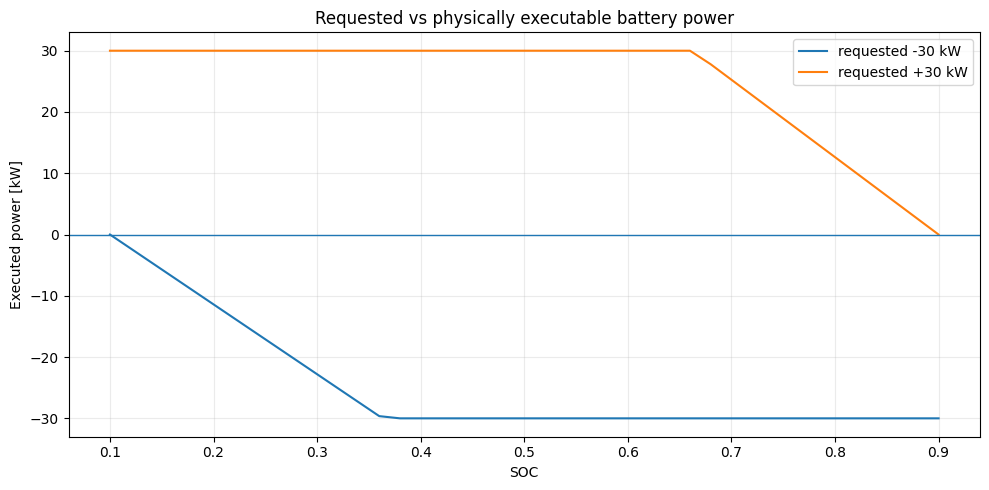

In [8]:
soc_grid = np.linspace(env.spec.min_soc, env.spec.max_soc, 41)
rows = []
for soc in soc_grid:
    env.soc = float(soc)
    for requested in [env.spec.max_charge_kw, -env.spec.max_discharge_kw]:
        executed, delta_e, throughput = env._clip_battery_power(requested)
        rows.append({"soc": soc, "requested_kw": requested, "executed_kw": executed})
clip_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
for req, part in clip_df.groupby("requested_kw"):
    ax.plot(part.soc, part.executed_kw, label=f"requested {req:+.0f} kW")
ax.axhline(0, linewidth=1)
ax.set_title("Requested vs physically executable battery power")
ax.set_xlabel("SOC"); ax.set_ylabel("Executed power [kW]"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb03_02_requested_vs_executed_limits.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Energy balance

Az AC bus oldali konvenció:

`grid_power = demand - renewable + battery_charging - battery_discharging`

Pozitív grid power = import. Negatív = export. Ez azért konzisztens, mert töltéskor plusz energiát kérünk a buszról, kisütéskor pedig az akkumulátor fedezi a demand egy részét.

In [9]:
demand = 80.0
renewable = 20.0
charge = 15.0
discharge = 0.0
grid = demand - renewable + charge - discharge
print(f"Demand={demand} kW, renewable={renewable} kW, charge={charge} kW -> grid import={grid} kW")
assert math.isclose(grid, 75.0)

Demand=80.0 kW, renewable=20.0 kW, charge=15.0 kW -> grid import=75.0 kW


## 9. Reward function — komponensekre bontva

A projektben a reward nem egy mágikus szám. Négy külön komponensből áll:

`reward = - electricity_cost - peak_penalty - degradation_penalty - constraint_penalty`

Az agent azt fogja optimalizálni, amit ebben a képletben megadunk. Ha például a degradation penalty túl kicsi, agresszíven ciklizálhat; ha túl nagy, szinte soha nem használja az akkumulátort.

In [10]:
from battery_rl.rewards import calculate_reward
example = calculate_reward(
    electricity_cost=8.0,
    grid_import_kw=82.0,
    peak_threshold_kw=70.0,
    throughput_kwh=20.0,
    requested_minus_executed_kwh=2.0,
    peak_penalty_eur_per_kw2=cfg["reward"]["peak_penalty_eur_per_kw2"],
    degradation_eur_per_kwh_throughput=cfg["reward"]["degradation_eur_per_kwh_throughput"],
    constraint_penalty_eur_per_kwh=cfg["reward"]["constraint_penalty_eur_per_kwh"],
)
example

RewardBreakdown(electricity_cost=8.0, peak_penalty=0.28800000000000003, degradation_penalty=0.08, constraint_penalty=0.16)

## 10. Egy teljes 24 órás environment rollout

Most egy egyszerű rule-szerű döntési sorozatot futtatunk. Nem azért, mert ez lesz a végső controller, hanem azért, hogy **minden transitiont meg tudjunk nézni**, mielőtt bármilyen RL algoritmus megtanulná kihasználni.

In [11]:
env = build_env(train, cfg, random_start=False)
obs, _ = env.reset(seed=42, options={"start_index": 0})
low = train.electricity_price_eur_per_kwh.quantile(0.30)
high = train.electricity_price_eur_per_kwh.quantile(0.75)
while True:
    price = float(env._row()["electricity_price_eur_per_kwh"])
    action = 0 if price < low else (2 if price > high else 1)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
log = env.episode_dataframe()
display(log.head(8))
print("Episode rows:", len(log), "Return:", round(log.reward.sum(), 3))

,timestamp,step,soc_before,soc,price,demand_kw,renewable_kw,requested_battery_power_kw,executed_battery_power_kw,charge_kw,discharge_kw,grid_power_kw,grid_import_kw,grid_export_kw,electricity_cost,peak_penalty,degradation_penalty,constraint_penalty,throughput_kwh,renewable_used_locally_kwh,renewable_generation_kwh,constraint_violation,reward
0,2024-07-01 00:00:00,0,0.5,0.5000,0.112899,44.164726,4.963247,0.0,0.0,0.0,-0.0,39.201479,39.201479,0.0,4.425819,0.0,0.000,0.0,0.0,4.963247,4.963247,0,-4.425819
1,2024-07-01 01:00:00,1,0.5,0.5000,0.103727,39.882054,0.159452,0.0,0.0,0.0,-0.0,39.722602,39.722602,0.0,4.120304,0.0,0.000,0.0,0.0,0.159452,0.159452,0,-4.120304
2,2024-07-01 02:00:00,2,0.5,0.5000,0.109841,45.709584,3.819218,0.0,0.0,0.0,-0.0,41.890366,41.890366,0.0,4.601268,0.0,0.000,0.0,0.0,3.819218,3.819218,0,-4.601268
3,2024-07-01 03:00:00,3,0.5,0.5000,0.112761,46.679056,0.000000,0.0,0.0,0.0,-0.0,46.679056,46.679056,0.0,5.263566,0.0,0.000,0.0,0.0,0.000000,0.000000,0,-5.263566
4,2024-07-01 04:00:00,4,0.5,0.5000,0.109132,38.431331,4.923360,0.0,0.0,0.0,-0.0,33.507971,33.507971,0.0,3.656787,0.0,0.000,0.0,0.0,4.923360,4.923360,0,-3.656787
5,2024-07-01 05:00:00,5,0.5,0.5000,0.111545,42.590233,0.957695,0.0,0.0,0.0,-0.0,41.632538,41.632538,0.0,4.643896,0.0,0.000,0.0,0.0,0.957695,0.957695,0,-4.643896
6,2024-07-01 06:00:00,6,0.5,0.5000,0.098014,50.267368,1.521757,0.0,0.0,0.0,-0.0,48.745611,48.745611,0.0,4.777735,0.0,0.000,0.0,0.0,1.521757,1.521757,0,-4.777735
7,2024-07-01 07:00:00,7,0.5,0.7375,0.092629,51.883896,20.463388,30.0,30.0,30.0,0.0,61.420508,61.420508,0.0,5.689337,0.0,0.114,0.0,28.5,20.463388,20.463388,0,-5.803337


Episode rows: 24 Return: -113.241


## 11. Price, SOC, battery power és grid import együtt

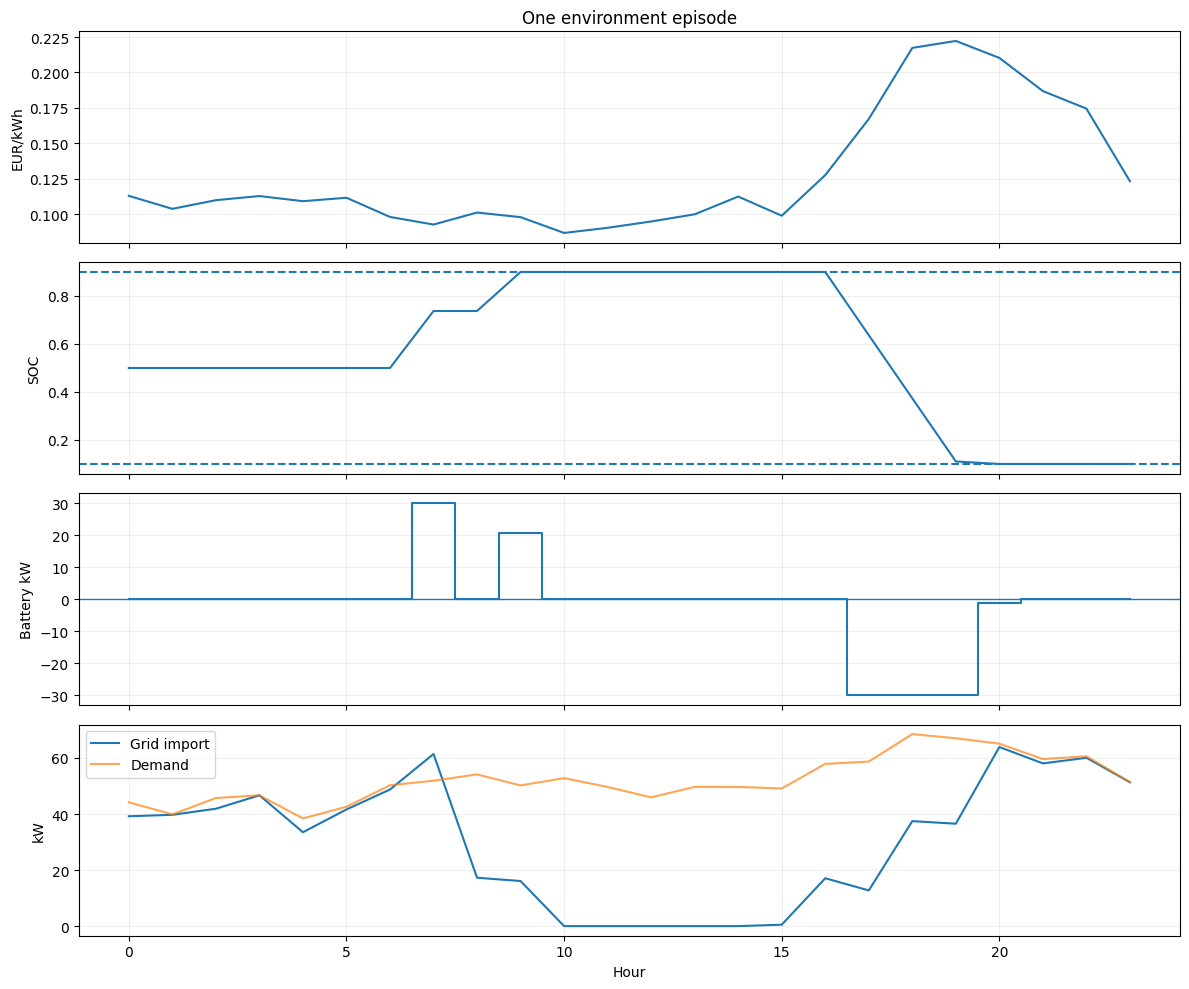

In [12]:
x = np.arange(len(log))
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(x, log.price); axes[0].set_ylabel("EUR/kWh"); axes[0].set_title("One environment episode")
axes[1].plot(x, log.soc); axes[1].axhline(env.spec.min_soc, linestyle="--"); axes[1].axhline(env.spec.max_soc, linestyle="--"); axes[1].set_ylabel("SOC")
axes[2].step(x, log.executed_battery_power_kw, where="mid"); axes[2].axhline(0, linewidth=1); axes[2].set_ylabel("Battery kW")
axes[3].plot(x, log.grid_import_kw, label="Grid import"); axes[3].plot(x, log.demand_kw, label="Demand", alpha=0.7); axes[3].set_ylabel("kW"); axes[3].set_xlabel("Hour"); axes[3].legend()
for ax in axes: ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb03_03_episode_dynamics.png", dpi=170, bbox_inches="tight")
plt.show()

## 12. Requested vs executed action az episode során

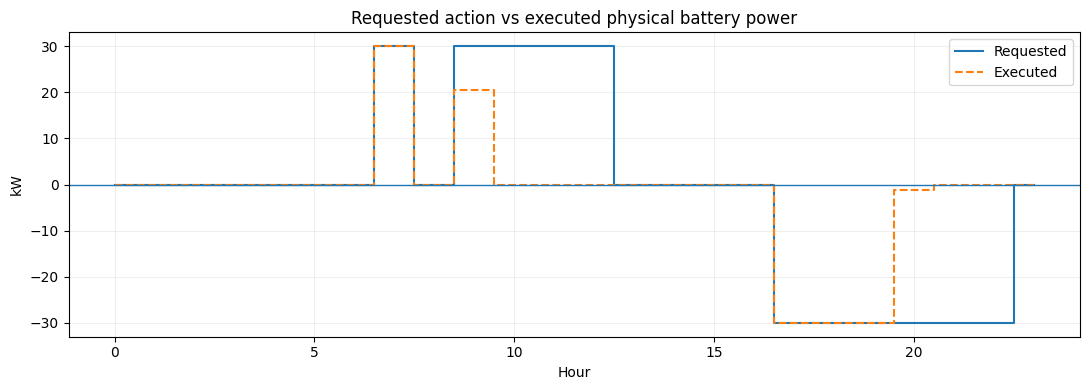

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.step(x, log.requested_battery_power_kw, where="mid", label="Requested")
ax.step(x, log.executed_battery_power_kw, where="mid", label="Executed", linestyle="--")
ax.axhline(0, linewidth=1)
ax.set_title("Requested action vs executed physical battery power")
ax.set_xlabel("Hour"); ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb03_04_requested_executed_episode.png", dpi=170, bbox_inches="tight")
plt.show()

## 13. Reward decomposition időben

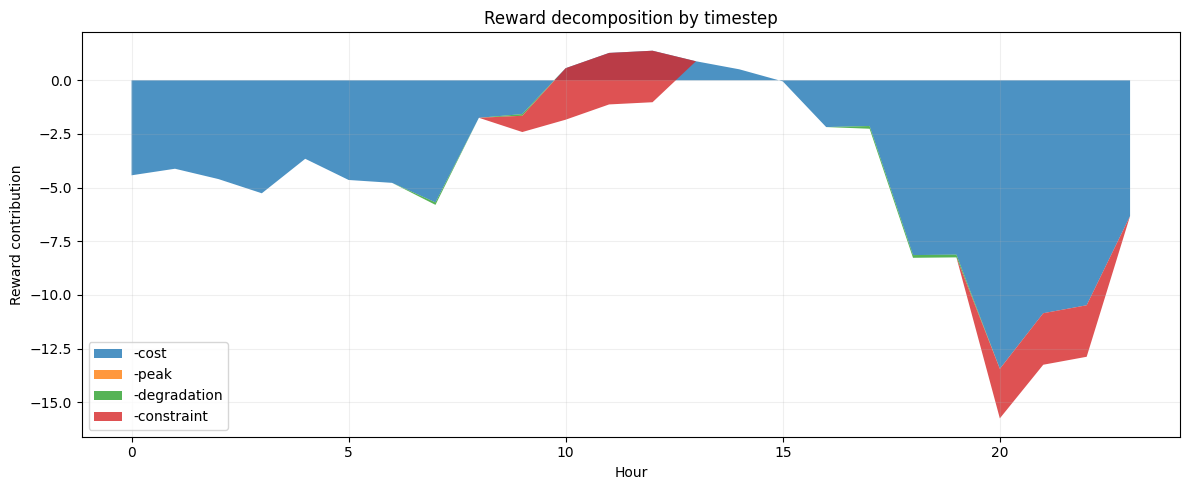

In [14]:
reward_components = pd.DataFrame({
    "-cost": -log.electricity_cost,
    "-peak": -log.peak_penalty,
    "-degradation": -log.degradation_penalty,
    "-constraint": -log.constraint_penalty,
})
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(x, *[reward_components[c].to_numpy() for c in reward_components.columns], labels=reward_components.columns, alpha=0.8)
ax.set_title("Reward decomposition by timestep")
ax.set_xlabel("Hour"); ax.set_ylabel("Reward contribution"); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb03_05_reward_decomposition.png", dpi=170, bbox_inches="tight")
plt.show()

## 14. Cumulative reward

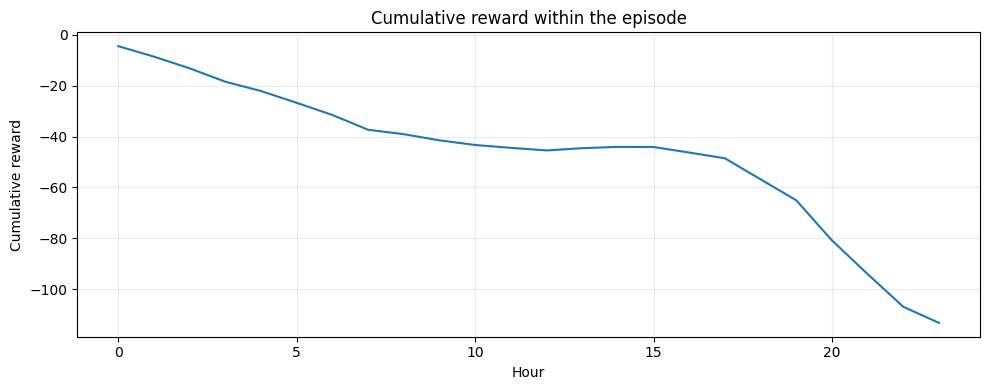

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, log.reward.cumsum())
ax.set_title("Cumulative reward within the episode")
ax.set_xlabel("Hour"); ax.set_ylabel("Cumulative reward"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb03_06_cumulative_reward.png", dpi=170, bbox_inches="tight")
plt.show()

## 15. Constraint események megtekintése

In [16]:
constraint_rows = log.loc[log.constraint_violation > 0, [
    "step", "soc_before", "soc", "requested_battery_power_kw", "executed_battery_power_kw", "constraint_violation"
]]
display(constraint_rows if len(constraint_rows) else pd.DataFrame({"message":["No clipped actions in this episode"]}))

,step,soc_before,soc,requested_battery_power_kw,executed_battery_power_kw,constraint_violation
9,9,0.737500,0.9,30.0,20.526316,1
10,10,0.900000,0.9,30.0,0.000000,1
11,11,0.900000,0.9,30.0,0.000000,1
12,12,0.900000,0.9,30.0,0.000000,1
20,20,0.110526,0.1,-30.0,-1.200000,1
21,21,0.100000,0.1,-30.0,-0.000000,1
22,22,0.100000,0.1,-30.0,-0.000000,1


## 16. Fizikai sanity checkek

Mielőtt RL-t tanítunk, érdemes explicit assertokkal ellenőrizni, hogy a környezet soha nem lépi túl a SOC- és power-korlátokat.

In [17]:
assert log.soc.between(env.spec.min_soc - 1e-9, env.spec.max_soc + 1e-9).all()
assert (log.executed_battery_power_kw <= env.spec.max_charge_kw + 1e-9).all()
assert (log.executed_battery_power_kw >= -env.spec.max_discharge_kw - 1e-9).all()
assert np.allclose(log.grid_power_kw, log.demand_kw - log.renewable_kw + log.charge_kw - log.discharge_kw)
print("All physical sanity checks passed.")

All physical sanity checks passed.


## Következtetés

Most már az RL agent előtt álló világ **explicit és ellenőrizhető**: ismerjük a state-et, actiont, transitiont, fizikai korlátokat és rewardot. A következő stepben először nem RL-t tanítunk, hanem erős baseline kontrollereket építünk, mert csak ezekhez viszonyítva lesz értelme bármilyen RL eredménynek.